## MODEL EVALUATION

evaluating how well the XGBoost model actually performs on data it has never seen before, the 20% test set that was held back during training. 

### Confusion Matrix
#### breakdown of correct and incorrect predictions
- True Negatives (13,382) — correctly predicted no default
- True Positives (239) — correctly caught defaulters
- False Negatives (13) — defaulters that were missed, costly for a bank
- False Positives (97) — flagged as defaulters but actually repaid so false alarms


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_curve, auc, precision_recall_curve, classification_report)
import joblib
import warnings
warnings.filterwarnings('ignore')

train = pd.read_csv(r'C:\Users\User\Desktop\credit-risk-project\data\processed\train_features.csv')
X = train.drop(columns=['target'])
y = train['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

xgb = joblib.load(r'C:\Users\User\Desktop\credit-risk-project\models\best_model.pkl')
scaler = joblib.load(r'C:\Users\User\Desktop\credit-risk-project\models\pipeline.pkl')

X_test_sc = scaler.transform(X_test)
y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:,1]

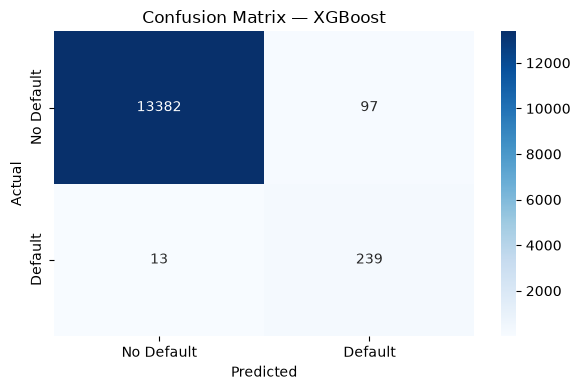

True Negatives: 13382
False Positives: 97
False Negatives: 13
True Positives: 239


In [2]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default', 'Default'],
            yticklabels=['No Default', 'Default'])
plt.title('Confusion Matrix — XGBoost')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()
print(f"True Negatives: {cm[0,0]}")
print(f"False Positives: {cm[0,1]}")
print(f"False Negatives: {cm[1,0]}")
print(f"True Positives: {cm[1,1]}")

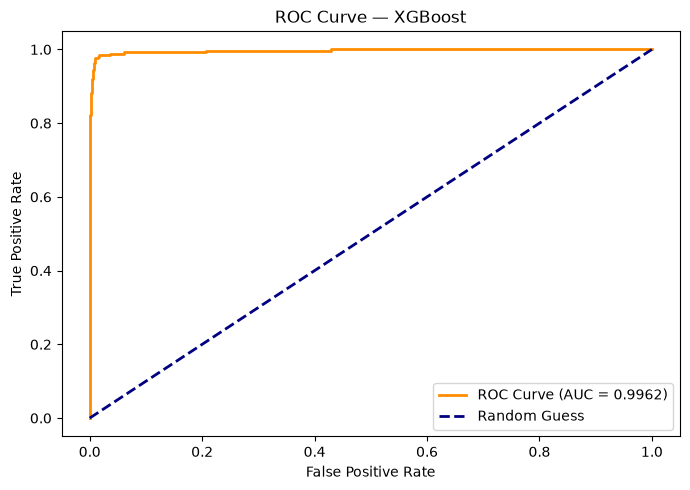

In [3]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], color='navy', lw=2, linestyle='--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — XGBoost')
plt.legend()
plt.tight_layout()
plt.show()

 #### ROC Curve
Shows the tradeoff between catching defaulters and raising false alarms at different thresholds. The AUC of 0.9962 means the model is near perfect (almost) at ranking defaulters as higher risk than non-defaulters.


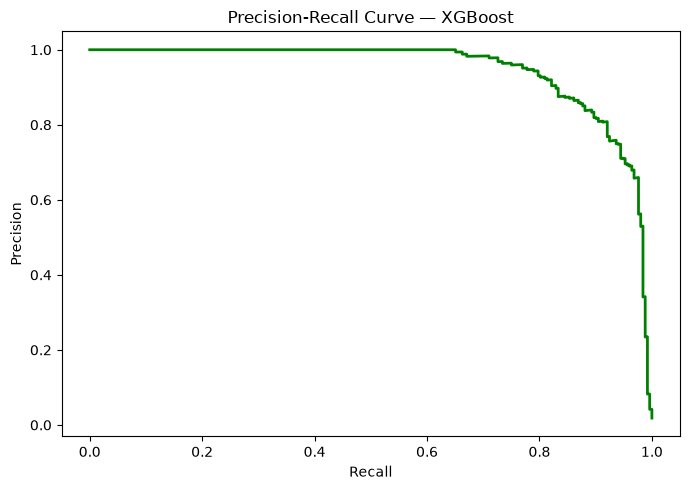

In [4]:
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(7,5))
plt.plot(recall, precision, color='green', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — XGBoost')
plt.tight_layout()
plt.show()

- will be right everytime it flags someone as a defaulter, even when recall increases

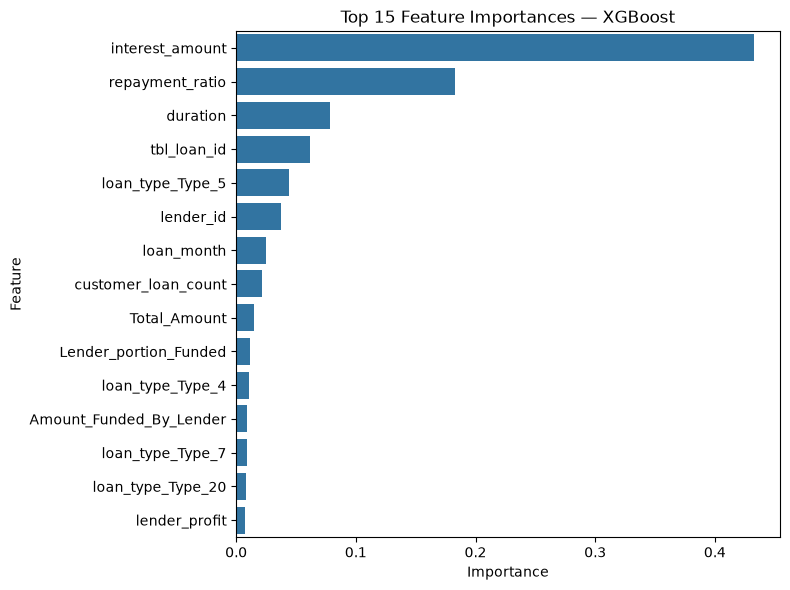

In [5]:
feature_names = joblib.load(r'C:\Users\User\Desktop\credit-risk-project\models\feature_names.pkl')
importances = xgb.feature_importances_
feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title('Top 15 Feature Importances — XGBoost')
plt.tight_layout()
plt.show()

### Feature Importance
Top predictors of default were:
- interest_amount — how much interest is charged on the loan taken
- repayment_ratio — ratio of repayment amount to loan amount
- duration — how long the loan runs
